# Visualize Noise in DDPM — 数学版

DDPM 论文定义的噪声：
- 正向过程: $q(x_t | x_0) = \mathcal{N}(x_t; \, \sqrt{\bar\alpha_t}\,x_0,\, (1-\bar\alpha_t)\mathbf{I})$
- 当 $t \to T$ 时 $\bar\alpha_T \approx 0$，$x_T \approx \mathcal{N}(0, \mathbf{I})$ — **纯白噪声**

只用 numpy + matplotlib，从数学出发构建。

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from math import pi, sqrt, exp

---
## 1. 纯白噪声：从 N(0, 1) 采样

$x \sim \mathcal{N}(0, \mathbf{I})$，每个像素独立同分布，概率密度函数：

$$f(x) = \frac{1}{\sqrt{2\pi}}\, e^{-\frac{x^2}{2}}$$

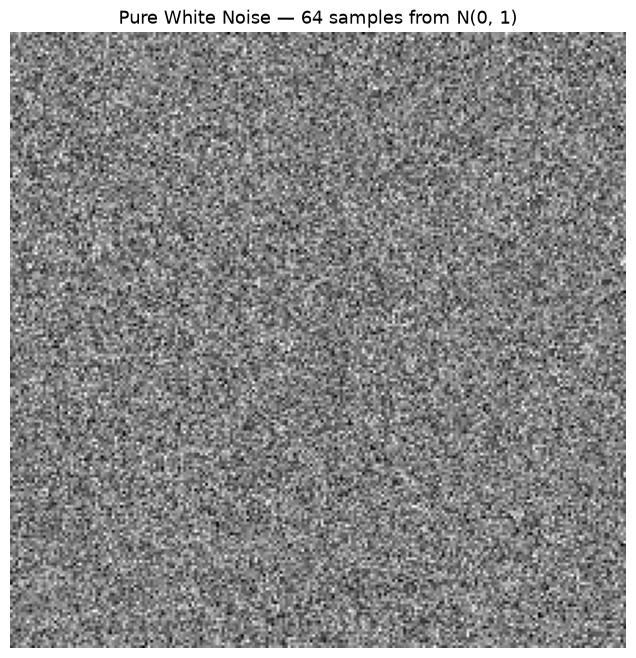

mean = -0.0005,  std = 1.0002  (theoretically 0, 1)


In [9]:
np.random.seed(42)

N_SAMPLES = 64       # 生成 64 个样本
IMG_SIZE = 28

# 从标准正态分布采样
noise = np.random.randn(N_SAMPLES, IMG_SIZE, IMG_SIZE)

# 拼成 8x8 网格展示
def make_grid(images, nrow=8):
    n, h, w = images.shape
    ncol = (n + nrow - 1) // nrow
    grid = np.zeros((ncol * h, nrow * w))
    for i in range(n):
        r, c = i // nrow, i % nrow
        grid[r*h:(r+1)*h, c*w:(c+1)*w] = images[i]
    return grid

grid = make_grid(noise)

plt.figure(figsize=(8, 8))
plt.imshow(grid, cmap="gray", vmin=-3, vmax=3)
plt.axis("off")
plt.title(f"Pure White Noise — {N_SAMPLES} samples from N(0, 1)", fontsize=13)
plt.savefig("samples/white_noise.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"mean = {noise.mean():.4f},  std = {noise.std():.4f}  (theoretically 0, 1)")

---
## 3. Forward Diffusion $q(x_t | x_0)$

用一张合成图像 $x_0$（白色圆盘）作为起点，观察它逐步被噪声淹没。

$$x_t = \sqrt{\bar\alpha_t}\,x_0 + \sqrt{1 - \bar\alpha_t}\,\epsilon,\quad \epsilon \sim \mathcal{N}(0, \mathbf{I})$$

其中 $\bar\alpha_t = \prod_{s=1}^t (1 - \beta_s)$，$\beta_s$ 是线性 schedule。

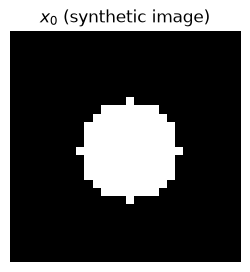

In [ ]:
# 创建一张 28x28 的合成图像：中心白色圆盘
x0 = np.zeros((IMG_SIZE, IMG_SIZE))
Y, X = np.ogrid[:IMG_SIZE, :IMG_SIZE]
mask = (X - IMG_SIZE/2)**2 + (Y - IMG_SIZE/2)**2 <= 6**2
x0[mask] = 1.0  # 白色
x0 = x0 * 2 - 1  # 缩放到 [-1, 1]

plt.figure(figsize=(3, 3))
plt.imshow(x0, cmap="gray", vmin=-1, vmax=1)
plt.title("$x_0$ (synthetic image)")
plt.axis("off")
plt.show()

In [ ]:
# 噪声 schedule (线性, DDPM 原版)
NUM_TIMESTEPS = 1000
beta_start, beta_end = 1e-4, 0.02

betas = np.linspace(beta_start, beta_end, NUM_TIMESTEPS)
alphas = 1.0 - betas
alpha_bars = np.cumprod(alphas)  # alpha_bar_t = prod_{s=1}^t alpha_s

print(f"alpha_bar[0]   = {alpha_bars[0]:.6f}")
print(f"alpha_bar[999] = {alpha_bars[-1]:.6f}  (≈0, so x_T ≈ pure noise)")

alpha_bar[0]   = 0.999900
alpha_bar[999] = 0.000040  (≈0, so x_T ≈ pure noise)


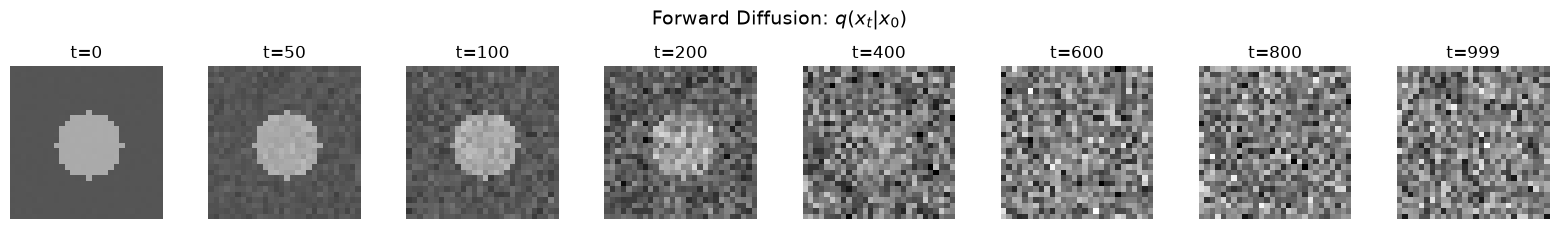

In [ ]:
timesteps = [0, 50, 100, 200, 400, 600, 800, 999]
fig, axes = plt.subplots(1, len(timesteps), figsize=(16, 2.2))

for i, t in enumerate(timesteps):
    a_bar_t = alpha_bars[t]
    eps = np.random.randn(IMG_SIZE, IMG_SIZE)
    xt = np.sqrt(a_bar_t) * x0 + np.sqrt(1.0 - a_bar_t) * eps
    axes[i].imshow(xt, cmap="gray", vmin=-3, vmax=3)
    axes[i].set_title(f"t={t}")
    axes[i].axis("off")

plt.suptitle("Forward Diffusion: $q(x_t | x_0)$", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("samples/forward_diffusion.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 4. Noise Schedule 可视化

- $\beta_t$：每一步的噪声方差
- $\bar\alpha_t$：信号保留比例 <- 关键：$\sqrt{\bar\alpha_t}$ 乘到 $x_0$ 上
- $1 - \bar\alpha_t$：噪声方差 <- 关键：$\sqrt{1 - \bar\alpha_t}$ 乘到 $\epsilon$ 上

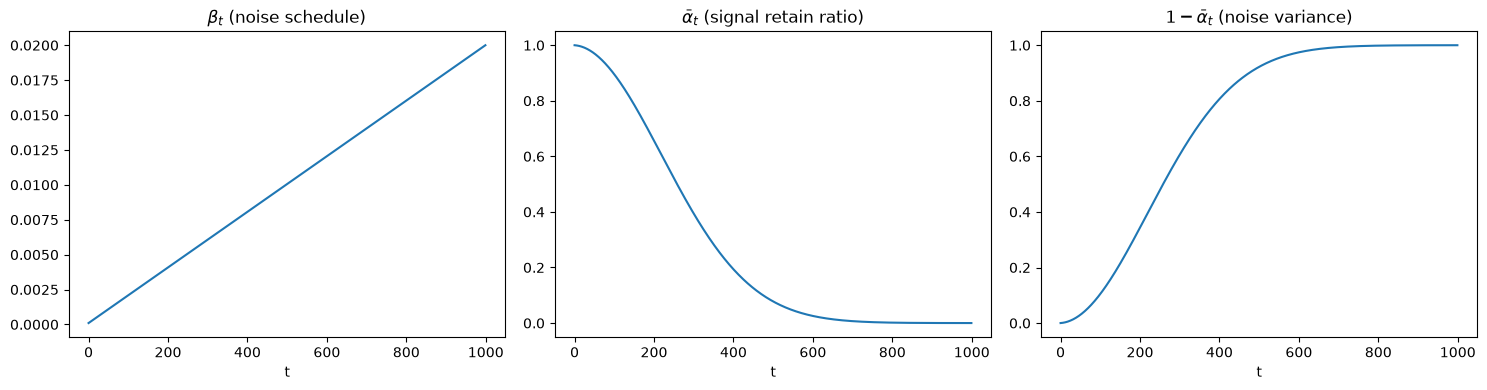

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(betas)
axes[0].set_title(r"$\beta_t$ (noise schedule)")
axes[0].set_xlabel("t")

axes[1].plot(alpha_bars)
axes[1].set_title(r"$\bar{\alpha}_t$ (signal retain ratio)")
axes[1].set_xlabel("t")

axes[2].plot(1 - alpha_bars)
axes[2].set_title(r"$1 - \bar{\alpha}_t$ (noise variance)")
axes[2].set_xlabel("t")

plt.tight_layout()
plt.savefig("samples/noise_schedule.png", dpi=150, bbox_inches="tight")
plt.show()